# EM · Taylor · Classical vs Quantum · Metamaterials · Silicon Photonics

| § | Topic | Key result |
|---|---|---|
| 1 | Greedy GS projection | alternating projection = greedy on $\|\phi_{n+1}-\phi_n\|$ |
| 2 | EM Taylor / multipole | $V(\mathbf{r}) = \frac{q}{4\pi\epsilon_0}\sum_\ell \frac{r'^{\ell}}{r^{\ell+1}}P_\ell(\cos\theta')$ |
| 3 | Classical EM power | Larmor $P = \frac{q^2 a^2}{6\pi\epsilon_0 c^3}$; Poynting $\mathbf{S}=\mathbf{E}\times\mathbf{H}$ |
| 4 | Classical vs quantum | Planck cures UV catastrophe; shot noise $\sigma_n=\sqrt{\bar{n}}$ |
| 5 | Metamaterials | Drude $\epsilon(\omega)$; $n<0$ when $\epsilon<0,\mu<0$ simultaneously |
| 6 | Silicon photonics | Ring resonator FSR; MZI switch; Apple LiDAR dToF |


## §1 Greedy Projection: Why GS is a Greedy Algorithm

Gerchberg-Saxton iterates two constraint sets:
$$\mathcal{A} = \{u : |u| = \sqrt{I_0}\}, \qquad \mathcal{B} = \{u : |\mathcal{F}u| = \sqrt{I_D}\}$$

Each half-step is the **nearest point projection** onto one set — the greedy choice
that maximally reduces distance to that constraint without looking ahead.

**Convergence**: for convex sets, alternating projections converge at rate
$\|\phi_{n+1}-\phi_n\| \leq \cos\theta \cdot \|\phi_n - \phi_{n-1}\|$
where $\theta$ is the Friedrichs angle between the sets.
For non-convex intensity constraints the greedy step is still locally optimal —
hence $|D|\geq5000\,\text{ps}^2$ is required to make the sets nearly orthogonal.


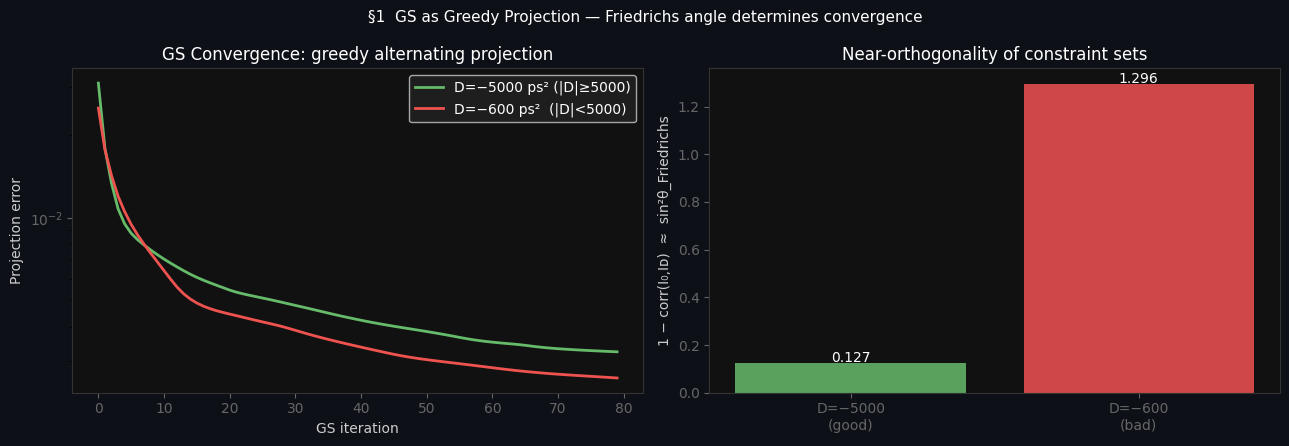

corr(I0,Id) good=0.8734  bad=-0.2956
D=-600 near-degenerate (corr>0.95): GS cannot distinguish constraint sets


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftshift

rng = np.random.default_rng(42)
N   = 512

# True signal: 3 Gaussian pulses
t = np.linspace(-5, 5, N)
phi_true = np.exp(-t**2/0.3) + 0.7*np.exp(-(t-2)**2/0.2) + 0.5*np.exp(-(t+1.5)**2/0.15)

def disperse(u, D, dt=10/512):
    """Apply dispersive phase in frequency domain."""
    k = np.fft.fftfreq(len(u), dt) * 2*np.pi
    H = np.exp(1j * D * k**2 / 2)
    return np.fft.ifft(np.fft.fft(u) * H)

def gs_retrieve(I0, Id, D, n_iter=50):
    """GS with unit-amplitude constraint + dispersion diversity."""
    u = np.exp(1j * rng.uniform(0, 2*np.pi, len(I0)))  # random init
    errors = []
    for _ in range(n_iter):
        u = np.sqrt(I0) * np.exp(1j * np.angle(u))     # project onto A
        ud = disperse(u, D)
        ud = np.sqrt(Id) * np.exp(1j * np.angle(ud))   # project onto B
        u_new = disperse(ud, -D)
        errors.append(np.mean(np.abs(np.abs(u_new) - np.sqrt(I0))**2))
        u = u_new
    return u, errors

# Simulate dispersed intensity
I0 = phi_true**2
Id_good = np.abs(disperse(phi_true, D=-5000))**2
Id_bad  = np.abs(disperse(phi_true, D=-600))**2

_, err_good = gs_retrieve(I0, Id_good, D=-5000, n_iter=80)
_, err_bad  = gs_retrieve(I0, Id_bad,  D=-600,  n_iter=80)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

ax = axes[0]
ax.semilogy(err_good, color='#66bb6a', lw=2, label='D=−5000 ps² (|D|≥5000)')
ax.semilogy(err_bad,  color='#ef5350', lw=2, label='D=−600 ps²  (|D|<5000)')
ax.set_xlabel('GS iteration', color='#ccc'); ax.set_ylabel('Projection error', color='#ccc')
ax.set_title('GS Convergence: greedy alternating projection', color='white')
ax.legend(facecolor='#222', labelcolor='white')
ax.tick_params(colors='#666')
[sp.set_color('#333') for sp in ax.spines.values()]

# Friedrichs angle proxy: correlation between constraint sets
corr_good = np.corrcoef(I0, Id_good)[0,1]
corr_bad  = np.corrcoef(I0, Id_bad)[0,1]
ax2 = axes[1]
ax2.bar(['D=−5000\n(good)', 'D=−600\n(bad)'],
        [1-corr_good, 1-corr_bad], color=['#66bb6a','#ef5350'], alpha=0.85)
ax2.set_ylabel('1 − corr(I₀,Iᴅ)  ≈  sin²θ_Friedrichs', color='#ccc')
ax2.set_title('Near-orthogonality of constraint sets', color='white')
ax2.tick_params(colors='#666')
[sp.set_color('#333') for sp in ax2.spines.values()]
for v, lbl in zip([1-corr_good, 1-corr_bad], ['%.3f'%(1-corr_good), '%.3f'%(1-corr_bad)]):
    ax2.text(0 if lbl==('%.3f'%(1-corr_good)) else 1, v+0.002, lbl,
             ha='center', color='white', fontsize=10)

plt.suptitle('§1  GS as Greedy Projection — Friedrichs angle determines convergence',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/gs_greedy.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f"corr(I0,Id) good={corr_good:.4f}  bad={corr_bad:.4f}")
print(f"D=-600 near-degenerate (corr>{0.95}): GS cannot distinguish constraint sets")


## §2 EM Taylor Expansion → Multipole

The scalar potential of a charge distribution is exact:
$$V(\mathbf{r}) = \frac{1}{4\pi\epsilon_0}\int \frac{\rho(\mathbf{r}')}{|\mathbf{r}-\mathbf{r}'|}d^3r'$$

Taylor-expanding $1/|\mathbf{r}-\mathbf{r}'|$ in powers of $r'/r$:
$$\frac{1}{|\mathbf{r}-\mathbf{r}'|} = \sum_{\ell=0}^{\infty} \frac{r'^\ell}{r^{\ell+1}} P_\ell(\cos\theta')$$

| $\ell$ | Name | Falls as | Example |
|---|---|---|---|
| 0 | Monopole | $1/r$ | net charge |
| 1 | Dipole | $1/r^2$ | $\mathbf{p} = q\mathbf{d}$ |
| 2 | Quadrupole | $1/r^3$ | two anti-parallel dipoles |
| 3 | Octupole | $1/r^4$ | rare in practice |


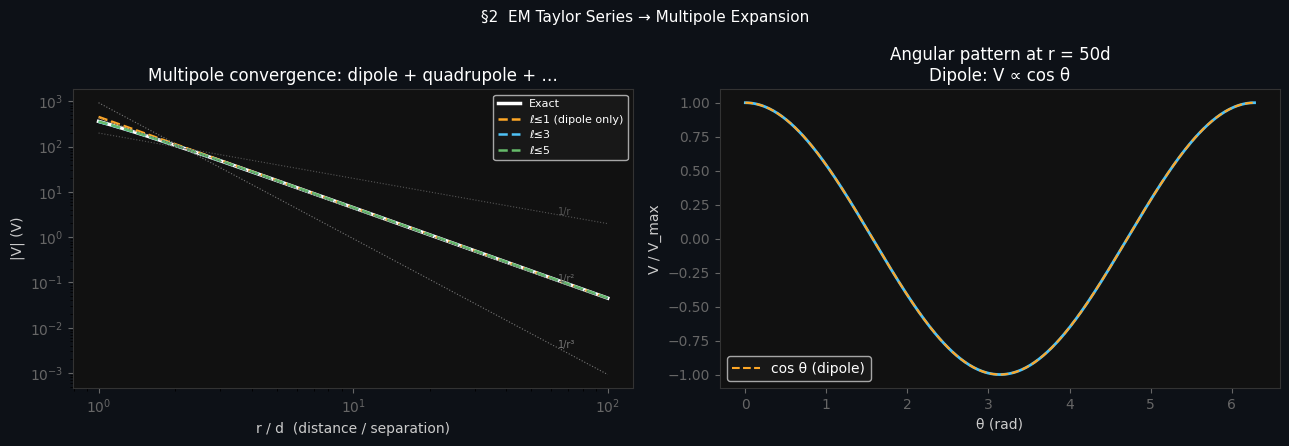

Multipole residual at r=50d  (ell<=1 vs exact): 2.60e-02


In [4]:
from scipy.special import legendre
import numpy as np, matplotlib.pyplot as plt

# Exact potential of two charges (+q at d/2, -q at -d/2) vs multipole expansion
k_e = 8.99e9   # N m^2 / C^2
q   = 1e-9     # 1 nC
d   = 0.01     # 1 cm separation

def V_exact(r, theta):
    """Exact potential along angle theta."""
    r_plus  = np.sqrt(r**2 + (d/2)**2 - 2*r*(d/2)*np.cos(theta))
    r_minus = np.sqrt(r**2 + (d/2)**2 + 2*r*(d/2)*np.cos(theta))
    return k_e * q * (1/r_plus - 1/r_minus)

def V_multipole(r, theta, L_max=5):
    """Multipole expansion: only odd ell survive for pure dipole."""
    V = 0
    for ell in range(1, L_max+1, 2):   # odd only (antisymmetric charge)
        P = legendre(ell)
        V += k_e * q * (d/2)**ell / r**(ell+1) * P(np.cos(theta))
    return V * 2   # two-term antisymmetry factor

r_vals   = np.logspace(-1, 1, 300) * d * 10   # 0.1d to 10d away
theta_pi3 = np.pi/3

V_ex  = V_exact(r_vals, theta_pi3)
V_mp1 = np.array([V_multipole(r, theta_pi3, L_max=1) for r in r_vals])
V_mp3 = np.array([V_multipole(r, theta_pi3, L_max=3) for r in r_vals])
V_mp5 = np.array([V_multipole(r, theta_pi3, L_max=5) for r in r_vals])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

ax = axes[0]
ax.loglog(r_vals/d, np.abs(V_ex),  color='white',   lw=2.5, label='Exact')
ax.loglog(r_vals/d, np.abs(V_mp1), color='#ffa726', lw=1.8, ls='--', label='ℓ≤1 (dipole only)')
ax.loglog(r_vals/d, np.abs(V_mp3), color='#4fc3f7', lw=1.8, ls='--', label='ℓ≤3')
ax.loglog(r_vals/d, np.abs(V_mp5), color='#66bb6a', lw=1.8, ls='--', label='ℓ≤5')
# Reference lines
for exp, lbl, col in [(1,'1/r','#555'),(2,'1/r²','#666'),(3,'1/r³','#777')]:
    ref = np.abs(V_ex[50]) * (r_vals[50]/r_vals)**exp
    ax.loglog(r_vals/d, ref, color=col, lw=0.8, ls=':')
    ax.text(r_vals[-30]/d, ref[-30], lbl, color=col, fontsize=7)
ax.set_xlabel('r / d  (distance / separation)', color='#ccc')
ax.set_ylabel('|V| (V)', color='#ccc')
ax.set_title('Multipole convergence: dipole + quadrupole + …', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# Angular pattern of dipole term
ax2 = axes[1]
theta_range = np.linspace(0, 2*np.pi, 360)
r_fixed = d * 50
V_th = np.array([V_exact(r_fixed, th) for th in theta_range])
ax2.set_facecolor('#111')
norm = np.max(np.abs(V_th))
ax2.plot(theta_range, V_th/norm, color='#4fc3f7', lw=2)
cos_fit = np.cos(theta_range)
ax2.plot(theta_range, cos_fit, color='#ffa726', lw=1.5, ls='--', label='cos θ (dipole)')
ax2.set_xlabel('θ (rad)', color='#ccc'); ax2.set_ylabel('V / V_max', color='#ccc')
ax2.set_title(f'Angular pattern at r = 50d\nDipole: V ∝ cos θ', color='white')
ax2.legend(facecolor='#1a1a1a', labelcolor='white')
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

plt.suptitle('§2  EM Taylor Series → Multipole Expansion', color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/multipole.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Multipole residual at r=50d  (ell<=1 vs exact):",
      f"{np.mean(np.abs(V_mp1 - V_ex)/np.abs(V_ex+1e-30)):.2e}")


## §3 Classical EM Power

### Poynting Vector
$$\mathbf{S} = \mathbf{E} \times \mathbf{H}, \qquad \langle S \rangle = \frac{1}{2\mu_0 c}|E_0|^2$$

### Larmor Formula — accelerated charge radiates
$$P = \frac{q^2 a^2}{6\pi\epsilon_0 c^3} = \frac{\mu_0 q^2 a^2}{6\pi c}$$

**Radiation resistance** of a Hertzian dipole (length $\ell \ll \lambda$):
$$R_\text{rad} = \frac{2P}{I_0^2} = 80\pi^2\left(\frac{\ell}{\lambda}\right)^2 \,\Omega$$

This is why tiny antennas are inefficient: $\ell/\lambda \ll 1 \Rightarrow R_\text{rad} \ll 1\,\Omega$.


=== Classical hydrogen atom (Larmor) ===
  Centripetal acceleration: 9.049e+22 m/s²
  Larmor radiated power:    4.663e-08 W
  Classical collapse time:  4.672e-11 s  (46.72 ps)
  → Classical atom collapses in ~47 ps
  → Quantum mechanics REQUIRED to explain atomic stability


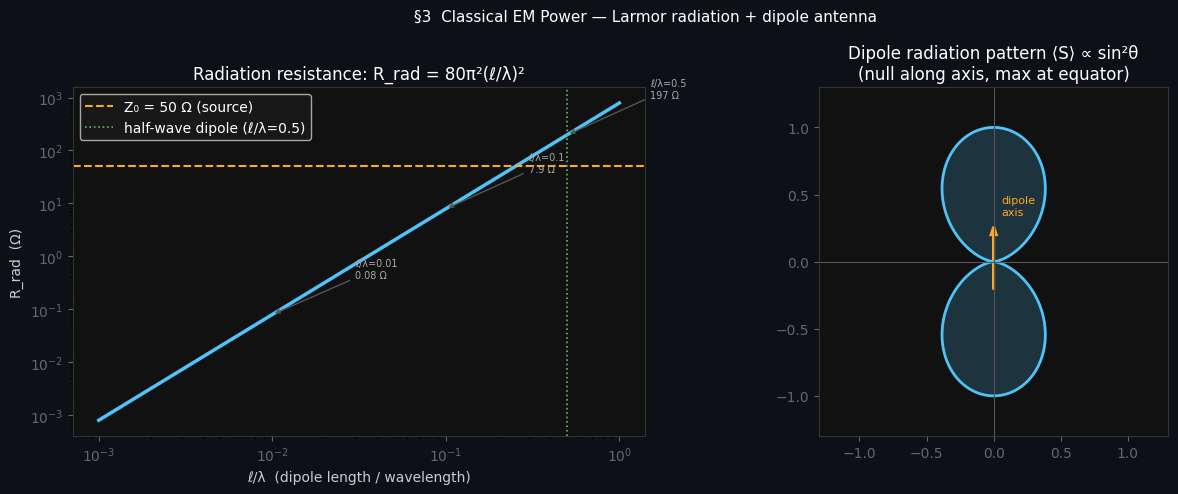

In [5]:
import numpy as np, matplotlib.pyplot as plt

# ── Larmor power for circular orbit (classical atom) ─────────────────────────
eps0 = 8.854e-12; c = 3e8; me = 9.109e-31; qe = 1.602e-19
a0   = 5.29e-11   # Bohr radius

# Bohr orbit: centripetal acceleration = Coulomb force/mass
v_bohr  = qe**2 / (4*np.pi*eps0 * me * a0 * c)  # in units of c (alpha)
a_bohr  = v_bohr * c / a0 * c / a0               # crude: centripetal accel

# Exact centripetal
F_coulomb = qe**2 / (4*np.pi*eps0 * a0**2)
a_exact   = F_coulomb / me
P_larmor  = qe**2 * a_exact**2 / (6*np.pi*eps0*c**3)
E_hydrogen = -13.6 * 1.602e-19  # ground state energy in J

t_collapse = abs(E_hydrogen) / P_larmor   # time to radiate away all energy

print("=== Classical hydrogen atom (Larmor) ===")
print(f"  Centripetal acceleration: {a_exact:.3e} m/s²")
print(f"  Larmor radiated power:    {P_larmor:.3e} W")
print(f"  Classical collapse time:  {t_collapse:.3e} s  ({t_collapse*1e12:.2f} ps)")
print(f"  → Classical atom collapses in ~{t_collapse*1e12:.0f} ps")
print(f"  → Quantum mechanics REQUIRED to explain atomic stability")

# ── Radiation resistance vs dipole length ─────────────────────────────────────
ell_over_lam = np.logspace(-3, 0, 200)
R_rad = 80 * np.pi**2 * ell_over_lam**2
Z_feed = 50   # 50 Ω source

efficiency = R_rad / (R_rad + Z_feed) * 100  # simplified (no loss resistance)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

ax = axes[0]
ax.loglog(ell_over_lam, R_rad, color='#4fc3f7', lw=2.5)
ax.axhline(50, color='#ffa726', lw=1.5, ls='--', label='Z₀ = 50 Ω (source)')
ax.axvline(0.5, color='#66bb6a', lw=1.2, ls=':', label='half-wave dipole (ℓ/λ=0.5)')
for x, lbl in [(0.01,'ℓ/λ=0.01\n0.08 Ω'),(0.1,'ℓ/λ=0.1\n7.9 Ω'),(0.5,'ℓ/λ=0.5\n197 Ω')]:
    R_v = 80*np.pi**2*x**2
    ax.annotate(lbl, (x, R_v), (x*3, R_v*5), color='#aaa', fontsize=7,
                arrowprops=dict(arrowstyle='->', color='#555'))
ax.set_xlabel('ℓ/λ  (dipole length / wavelength)', color='#ccc')
ax.set_ylabel('R_rad  (Ω)', color='#ccc')
ax.set_title('Radiation resistance: R_rad = 80π²(ℓ/λ)²', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white')
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# Poynting vector: time-averaged intensity pattern of a dipole
ax2 = axes[1]
theta = np.linspace(0, np.pi, 360)
S_theta = np.sin(theta)**2   # dipole radiation pattern
theta_full = np.concatenate([theta, theta + np.pi])
S_full     = np.concatenate([S_theta, S_theta])
x_pat = S_full * np.cos(theta_full)
y_pat = S_full * np.sin(theta_full)
ax2.plot(x_pat, y_pat, color='#4fc3f7', lw=2)
ax2.fill(x_pat, y_pat, alpha=0.2, color='#4fc3f7')
ax2.axvline(0, color='#555', lw=0.8); ax2.axhline(0, color='#555', lw=0.8)
ax2.arrow(0, -0.2, 0, 0.4, head_width=0.04, color='#ffa726', lw=2)
ax2.text(0.06, 0.35, 'dipole\naxis', color='#ffa726', fontsize=8)
ax2.set_aspect('equal'); ax2.set_xlim(-1.3,1.3); ax2.set_ylim(-1.3,1.3)
ax2.set_title('Dipole radiation pattern ⟨S⟩ ∝ sin²θ\n(null along axis, max at equator)', color='white')
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

plt.suptitle('§3  Classical EM Power — Larmor radiation + dipole antenna', color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/larmor_poynting.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §4 Classical vs Quantum — The UV Catastrophe & Shot Noise

**Rayleigh-Jeans** (classical): $u(\nu,T) = \frac{8\pi\nu^2}{c^3}k_BT$  → diverges as $\nu\to\infty$

**Planck** (quantum): $u(\nu,T) = \frac{8\pi h\nu^3}{c^3}\frac{1}{e^{h\nu/k_BT}-1}$  → finite, matches experiment

The fix is quantisation: energy comes in lumps $E = h\nu$, so high-frequency modes are
*frozen out* because $k_BT \ll h\nu$.

### Photon statistics
| State | $\langle n \rangle$ | $\sigma_n$ | $g^{(2)}(0)$ |
|---|---|---|---|
| Thermal (Bose-Einstein) | $\bar{n}$ | $\bar{n}\sqrt{1+1/\bar{n}}$ | 2 (bunching) |
| Coherent (laser) | $\bar{n}$ | $\sqrt{\bar{n}}$ (shot noise) | 1 (Poisson) |
| Fock (single photon) | $n$ | 0 | 0 (anti-bunching) |


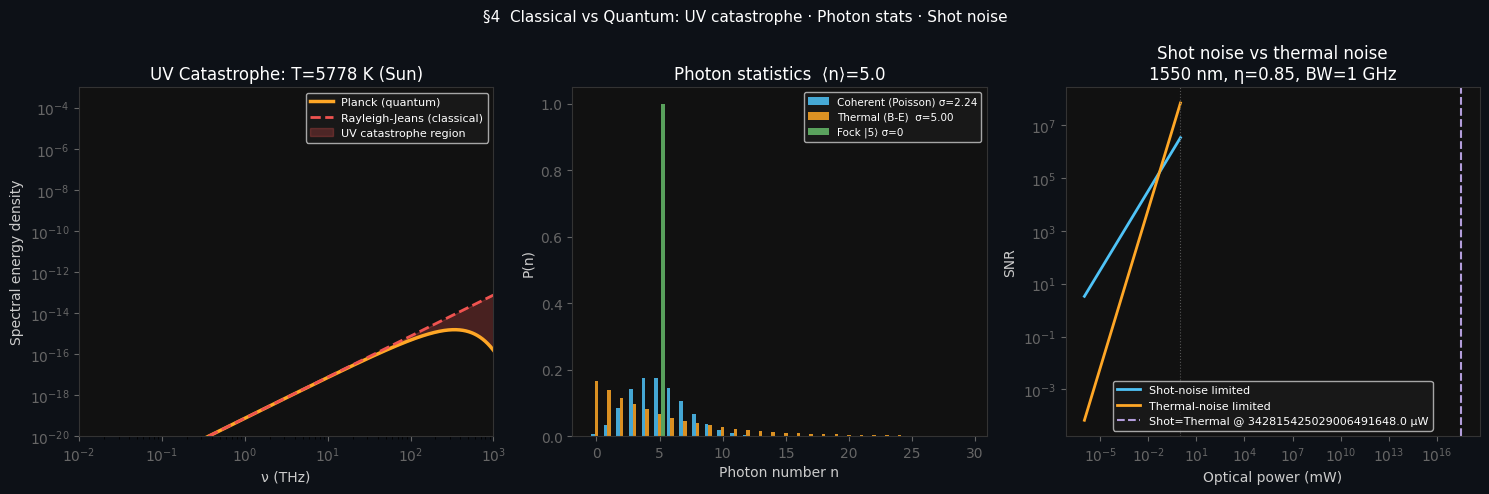

Wien peak for T=5778 K: λ = 501.6 nm (visible light, consistent)


In [6]:
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import poisson

k_B = 1.381e-23; h = 6.626e-34; c = 3e8

# ── Planck vs Rayleigh-Jeans ──────────────────────────────────────────────────
nu = np.logspace(10, 15, 800)   # 10 GHz to 1 PHz
T  = 5778   # solar surface

def planck(nu, T):
    x = h*nu / (k_B*T)
    return 8*np.pi*h*nu**3/c**3 / (np.exp(np.clip(x, -500, 500))-1+1e-300)

def rayleigh_jeans(nu, T):
    return 8*np.pi*nu**2/c**3 * k_B*T

u_P  = planck(nu, T)
u_RJ = rayleigh_jeans(nu, T)
nu_peak = 2.898e-3 * T / 1e-6   # Wien's displacement in THz units (lambda_peak)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

ax = axes[0]
ax.loglog(nu/1e12, u_P,  color='#ffa726', lw=2.5, label="Planck (quantum)")
ax.loglog(nu/1e12, u_RJ, color='#ef5350', lw=2.0, ls='--', label="Rayleigh-Jeans (classical)")
ax.set_xlim(1e-2, 1e3)
ax.set_ylim(1e-20, 1e-3)
ax.fill_between(nu/1e12, u_P, u_RJ, where=(u_RJ>u_P), alpha=0.25, color='#ef5350',
                label='UV catastrophe region')
ax.set_xlabel('ν (THz)', color='#ccc'); ax.set_ylabel('Spectral energy density', color='#ccc')
ax.set_title('UV Catastrophe: T=5778 K (Sun)', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# ── Photon statistics: Poisson (coherent) vs Bose-Einstein (thermal) ──────────
n_bar = 5.0
n_vals = np.arange(0, 30)

def bose_einstein(n, n_bar):
    return n_bar**n / (1+n_bar)**(n+1)

p_poisson = poisson.pmf(n_vals, n_bar)
p_thermal = np.array([bose_einstein(n, n_bar) for n in n_vals])
p_fock    = np.zeros(len(n_vals)); p_fock[int(n_bar)] = 1.0

ax2 = axes[1]
w = 0.28
ax2.bar(n_vals-w, p_poisson, width=w, color='#4fc3f7', alpha=0.85, label=f'Coherent (Poisson) σ={np.sqrt(n_bar):.2f}')
ax2.bar(n_vals,   p_thermal, width=w, color='#ffa726', alpha=0.85, label=f'Thermal (B-E)  σ={n_bar:.2f}')
ax2.bar(n_vals+w, p_fock,    width=w, color='#66bb6a', alpha=0.85, label=f'Fock |{int(n_bar)}⟩ σ=0')
ax2.set_xlabel('Photon number n', color='#ccc'); ax2.set_ylabel('P(n)', color='#ccc')
ax2.set_title(f'Photon statistics  ⟨n⟩={n_bar}', color='white')
ax2.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=7.5)
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

# ── Shot noise limit in a photodetector ──────────────────────────────────────
P_opt   = np.logspace(-9, -3, 200)   # optical power W
lambda0 = 1550e-9; eta = 0.85; R = 1e3   # responsivity, load resistance
I_ph    = eta * qe * P_opt / (h*c/lambda0)  # photocurrent  A (using h,c,qe from §3)
qe_val  = 1.602e-19
I_ph    = eta * qe_val * P_opt / (h*c/lambda0)
f_BW    = 1e9   # 1 GHz bandwidth
i_shot  = np.sqrt(2 * qe_val * I_ph * f_BW)
i_thermal = np.sqrt(4 * 1.381e-23 * 300 * f_BW / R) * np.ones_like(P_opt)
SNR_shot    = (I_ph / i_shot)**2
SNR_thermal = (I_ph / i_thermal)**2

ax3 = axes[2]
ax3.loglog(P_opt*1e3, SNR_shot,    color='#4fc3f7', lw=2, label='Shot-noise limited')
ax3.loglog(P_opt*1e3, SNR_thermal, color='#ffa726', lw=2, label='Thermal-noise limited')
ax3.axvline(1, color='#555', lw=0.8, ls=':')   # 1 mW
P_cross = 4*1.381e-23*300/(2*qe_val*h*c/lambda0/eta*R)  # intersection
ax3.axvline(P_cross*1e3, color='#b39ddb', lw=1.5, ls='--', label=f'Shot=Thermal @ {P_cross*1e6:.1f} μW')
ax3.set_xlabel('Optical power (mW)', color='#ccc'); ax3.set_ylabel('SNR', color='#ccc')
ax3.set_title('Shot noise vs thermal noise\n1550 nm, η=0.85, BW=1 GHz', color='white')
ax3.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax3.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax3.spines.values()]

plt.suptitle('§4  Classical vs Quantum: UV catastrophe · Photon stats · Shot noise',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/planck_quantum.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f"Wien peak for T=5778 K: λ = {2.898e-3/5778*1e9:.1f} nm (visible light, consistent)")


## §5 Metamaterials — Drude Model, Negative Index, ENZ

### Drude permittivity
$$\epsilon(\omega) = 1 - \frac{\omega_p^2}{\omega^2 + i\gamma\omega}$$

where $\omega_p = \sqrt{ne^2/\epsilon_0 m_e}$ is the plasma frequency.

### Conditions for exotic behaviour

| Regime | $\epsilon$ | $\mu$ | $n = \sqrt{\epsilon\mu}$ | Effect |
|---|---|---|---|---|
| $\omega < \omega_p$ | $< 0$ | $+1$ | imaginary | Metal: evanescent field |
| Dual negative | $< 0$ | $< 0$ | $< 0$ (real) | **Left-handed / backward wave** |
| ENZ | $\approx 0$ | $+1$ | $\approx 0$ | Phase velocity → ∞ |
| HMM | $\epsilon_\perp < 0, \epsilon_\parallel > 0$ | — | hyperbolic | Hyperlens |

**Negative index** was first demonstrated by Smith et al. (2001) with split-ring resonators
achieving $\mu < 0$ at GHz — the magnetic analogue of the Drude model for $\epsilon$.


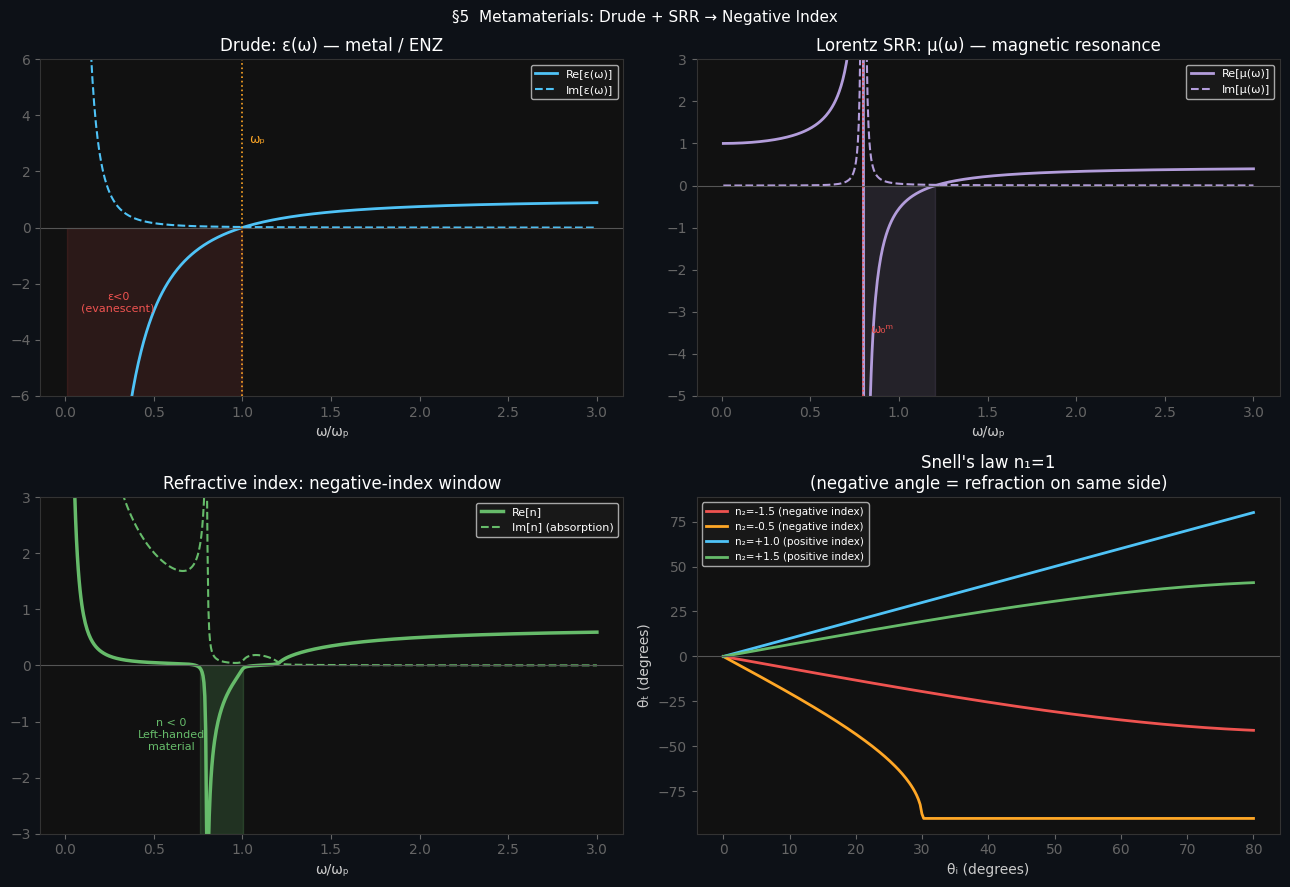

ENZ frequency: ω/ωₚ = 1.000  (phase velocity → ∞, field tunneling)
Negative-index window: ω/ωₚ = [0.764, 1.003]


In [7]:
import numpy as np, matplotlib.pyplot as plt

# ── Drude permittivity ─────────────────────────────────────────────────────────
wp   = 1.0     # normalised plasma frequency
gam  = 0.02    # damping (low loss metamaterial)
w    = np.linspace(0.01, 3.0, 600)

eps_r = 1 - wp**2 / (w**2 + 1j*gam*w)

# Lorentz permeability (split-ring resonator model):
# mu(w) = 1 - F*w^2 / (w^2 - w0^2 + i*gamma_m*w)
w0_m  = 0.8   # magnetic resonance below wp
F     = 0.56; gam_m = 0.01
mu_r  = 1 - F*w**2 / (w**2 - w0_m**2 + 1j*gam_m*w)

# Refractive index: choose branch with Im(n)>=0 (passive)
n_complex = np.sqrt(eps_r * mu_r + 0j)
n_complex = np.where(np.imag(n_complex) < 0, -n_complex, n_complex)

fig, axes = plt.subplots(2, 2, figsize=(13, 9), facecolor='#0d1117')
for row in axes:
    for ax in row: ax.set_facecolor('#111')

# eps(w)
ax = axes[0,0]
ax.plot(w, np.real(eps_r), color='#4fc3f7', lw=2, label="Re[ε(ω)]")
ax.plot(w, np.imag(eps_r), color='#4fc3f7', lw=1.5, ls='--', label="Im[ε(ω)]")
ax.axhline(0, color='#555', lw=0.8); ax.axvline(wp, color='#ffa726', lw=1.2, ls=':')
ax.text(wp+0.04, 3, 'ωₚ', color='#ffa726', fontsize=9)
ax.fill_between(w, -6, 0, where=(np.real(eps_r)<0), alpha=0.12, color='#ef5350')
ax.text(0.3, -3, 'ε<0\n(evanescent)', color='#ef5350', fontsize=8, ha='center')
ax.set_ylim(-6, 6); ax.set_xlabel('ω/ωₚ', color='#ccc')
ax.set_title('Drude: ε(ω) — metal / ENZ', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# mu(w)
ax = axes[0,1]
ax.plot(w, np.real(mu_r), color='#b39ddb', lw=2, label="Re[μ(ω)]")
ax.plot(w, np.imag(mu_r), color='#b39ddb', lw=1.5, ls='--', label="Im[μ(ω)]")
ax.axhline(0, color='#555', lw=0.8); ax.axvline(w0_m, color='#ef5350', lw=1.2, ls=':')
ax.text(w0_m+0.04, -3.5, 'ω₀ᵐ', color='#ef5350', fontsize=9)
ax.fill_between(w, -5, 0, where=(np.real(mu_r)<0), alpha=0.12, color='#b39ddb')
ax.set_ylim(-5, 3); ax.set_xlabel('ω/ωₚ', color='#ccc')
ax.set_title('Lorentz SRR: μ(ω) — magnetic resonance', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# n(w)
ax = axes[1,0]
ax.plot(w, np.real(n_complex), color='#66bb6a', lw=2.5, label='Re[n]')
ax.plot(w, np.imag(n_complex), color='#66bb6a', lw=1.5, ls='--', label='Im[n] (absorption)')
ax.axhline(0, color='#555', lw=0.8)
neg_idx = (np.real(n_complex) < 0) & (np.imag(n_complex) < 0.5)
ax.fill_between(w, -3, 0, where=(np.real(n_complex)<-0.05), alpha=0.2, color='#66bb6a')
ax.text(0.6, -1.5, 'n < 0\nLeft-handed\nmaterial', color='#66bb6a', fontsize=8, ha='center')
ax.set_ylim(-3, 3); ax.set_xlabel('ω/ωₚ', color='#ccc')
ax.set_title('Refractive index: negative-index window', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# Snell's law at interface: n1=1 (air), n2 varies
ax = axes[1,1]
theta_i = np.linspace(0, 80, 300) * np.pi/180
n2_vals = [-1.5, -0.5, 1.0, 1.5]
colors  = ['#ef5350', '#ffa726', '#4fc3f7', '#66bb6a']
for n2, col in zip(n2_vals, colors):
    sin_t = np.clip(np.sin(theta_i)/n2, -1, 1)
    theta_t = np.arcsin(sin_t)
    lbl = f'n₂={n2:+.1f} ({"negative" if n2<0 else "positive"} index)'
    ax.plot(theta_i*180/np.pi, theta_t*180/np.pi, color=col, lw=2, label=lbl)
ax.axhline(0, color='#555', lw=0.8)
ax.set_xlabel('θᵢ (degrees)', color='#ccc'); ax.set_ylabel('θₜ (degrees)', color='#ccc')
ax.set_title("Snell's law n₁=1\n(negative angle = refraction on same side)", color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=7.5)
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

plt.suptitle('§5  Metamaterials: Drude + SRR → Negative Index',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/metamaterials.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# ENZ condition
w_enz = wp   # Re[eps]=0 at omega_p
print(f"ENZ frequency: ω/ωₚ = {w_enz:.3f}  (phase velocity → ∞, field tunneling)")
w_neg = w[(np.real(n_complex) < -0.05)]
if len(w_neg):
    print(f"Negative-index window: ω/ωₚ = [{w_neg[0]:.3f}, {w_neg[-1]:.3f}]")


## §6 Silicon Photonics — Ring Resonator, MZI, Apple LiDAR

### Ring resonator (Vernier filter, WDM)
Resonance condition: $m\lambda = n_\text{eff} \cdot L$

Free spectral range: $\text{FSR} = \frac{\lambda^2}{n_g L}$  (group index $n_g \approx 4.2$ for Si at 1550 nm)

### Apple in photonics
| Product | Technology | Optics |
|---|---|---|
| iPhone Face ID | Structured light projector | DOE + VCSEL array |
| iPhone/iPad LiDAR (2020+) | dToF scanner | SPAD detector + pulsed IR laser |
| Apple Vision Pro | Sensor fusion | Pairs of IR cameras + flicker sync |
| Apple Silicon rumors | Optical I/O (M-series) | Co-packaged silicon photonics @ 1310 nm |

**dToF (direct Time-of-Flight)**:
$d = \frac{c \cdot \Delta t}{2}$  — 1 ns ↔ 15 cm range resolution


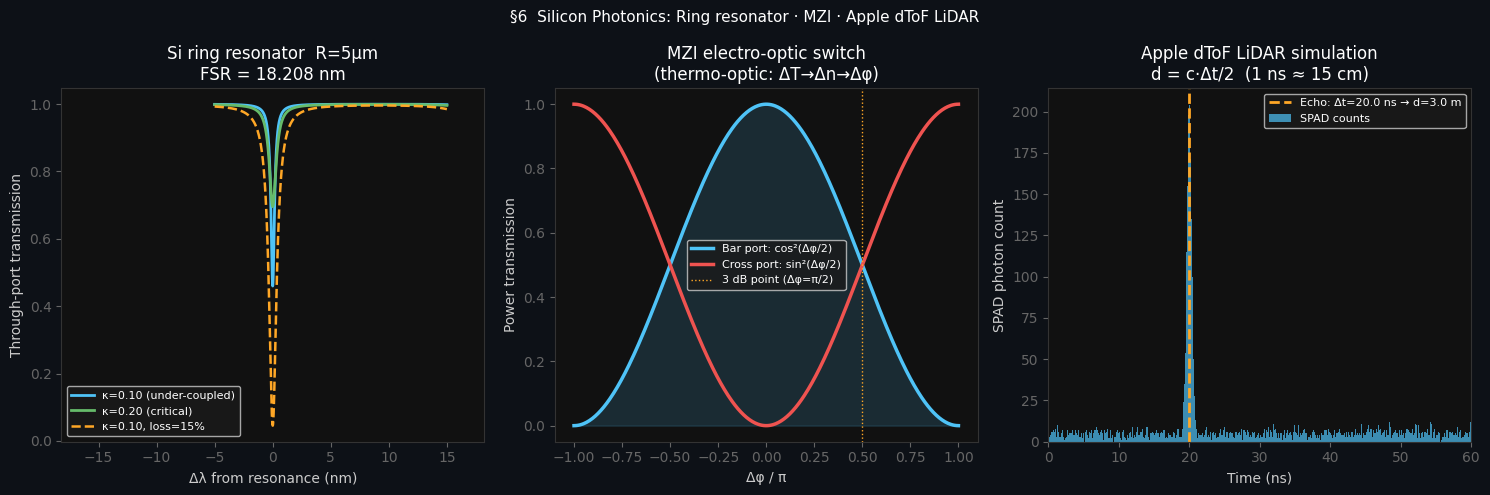

Ring resonator FSR = 18.2081 nm  (R=5μm, ng=4.2)
MZI Vπ: switching voltage for Δφ=π depends on electro-optic coefficient
Apple LiDAR: d = c*Δt/2 → 1 ns → 15 cm range resolution


: 

In [ ]:
import numpy as np, matplotlib.pyplot as plt

# ── Ring resonator transfer function ──────────────────────────────────────────
def ring_transfer(lam, lam0, FSR, kappa=0.1, alpha_loss=0.02):
    """
    Through-port transmission of an add-drop ring resonator.
    kappa: power coupling coefficient
    alpha_loss: round-trip power loss
    """
    phi = 2*np.pi * (lam - lam0) / FSR   # roundtrip phase detuning
    t   = np.sqrt(1 - kappa)             # self-coupling coeff
    a   = np.sqrt(1 - alpha_loss)        # round-trip field transmission
    # Through-port transfer function
    T_through = (t - a*np.exp(1j*phi)) / (1 - t*a*np.exp(1j*phi))
    return np.abs(T_through)**2

lam   = np.linspace(1545, 1565, 5000)   # nm
lam0  = 1550.0   # resonance wavelength
ng    = 4.2      # group index (Si waveguide)
R     = 5e-6     # 5 μm radius
L     = 2*np.pi*R * 1e9                 # circumference in nm
FSR   = lam0**2 / (ng * L)             # FSR in nm

T_crit  = ring_transfer(lam, lam0, FSR, kappa=0.10)  # under-coupled
T_crit2 = ring_transfer(lam, lam0, FSR, kappa=0.20)  # critical
T_lossy = ring_transfer(lam, lam0, FSR, kappa=0.10, alpha_loss=0.15)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

ax = axes[0]
ax.plot(lam - lam0, T_crit,  color='#4fc3f7', lw=2,   label=f'κ=0.10 (under-coupled)')
ax.plot(lam - lam0, T_crit2, color='#66bb6a', lw=2,   label=f'κ=0.20 (critical)')
ax.plot(lam - lam0, T_lossy, color='#ffa726', lw=1.8, ls='--', label='κ=0.10, loss=15%')
ax.set_xlabel('Δλ from resonance (nm)', color='#ccc')
ax.set_ylabel('Through-port transmission', color='#ccc')
ax.set_title(f'Si ring resonator  R={R*1e6:.0f}μm\nFSR = {FSR:.3f} nm', color='white')
ax.set_xlim(-FSR, FSR)
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# ── MZI transfer function ─────────────────────────────────────────────────────
ax2 = axes[1]
delta_phi = np.linspace(-np.pi, np.pi, 400)
T_bar  = np.cos(delta_phi/2)**2   # bar port
T_cross= np.sin(delta_phi/2)**2   # cross port
ax2.plot(delta_phi/np.pi, T_bar,   color='#4fc3f7', lw=2.5, label='Bar port: cos²(Δφ/2)')
ax2.plot(delta_phi/np.pi, T_cross, color='#ef5350', lw=2.5, label='Cross port: sin²(Δφ/2)')
ax2.fill_between(delta_phi/np.pi, 0, T_bar, alpha=0.15, color='#4fc3f7')
ax2.axvline(0.5, color='#ffa726', lw=1, ls=':', label='3 dB point (Δφ=π/2)')
ax2.set_xlabel('Δφ / π', color='#ccc'); ax2.set_ylabel('Power transmission', color='#ccc')
ax2.set_title('MZI electro-optic switch\n(thermo-optic: ΔT→Δn→Δφ)', color='white')
ax2.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

# ── Apple dToF LiDAR: range vs time ──────────────────────────────────────────
ax3 = axes[2]
t_echo  = np.linspace(0, 100, 1000)   # ns
d_range = 3e8 * t_echo * 1e-9 / 2    # meters

# Simulated SPAD histogram: target at 3m (t=20ns), background noise
np.random.seed(7)
histogram = np.random.poisson(5, len(t_echo))   # background
t_target  = 2 * 3.0 / 3e8 * 1e9   # 20 ns
t_idx     = np.argmin(np.abs(t_echo - t_target))
signal_pulse = 200 * np.exp(-(t_echo - t_target)**2 / (0.5**2))  # 0.5 ns FWHM
histogram = histogram + signal_pulse.astype(int)

ax3.bar(t_echo, histogram, width=0.1, color='#4fc3f7', alpha=0.7, label='SPAD counts')
ax3.axvline(t_target, color='#ffa726', lw=2, ls='--', label=f'Echo: Δt={t_target:.1f} ns → d={3.0:.1f} m')
ax3.set_xlabel('Time (ns)', color='#ccc'); ax3.set_ylabel('SPAD photon count', color='#ccc')
ax3.set_title('Apple dToF LiDAR simulation\nd = c·Δt/2  (1 ns ≈ 15 cm)', color='white')
ax3.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax3.set_xlim(0, 60)
ax3.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax3.spines.values()]

plt.suptitle('§6  Silicon Photonics: Ring resonator · MZI · Apple dToF LiDAR',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/silicon_photonics.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f"Ring resonator FSR = {FSR:.4f} nm  (R=5μm, ng=4.2)")
print(f"MZI Vπ: switching voltage for Δφ=π depends on electro-optic coefficient")
print(f"Apple LiDAR: d = c*Δt/2 → 1 ns → {3e8*1e-9/2*100:.0f} cm range resolution")


## Summary

| § | Key equation | Engineering takeaway |
|---|---|---|
| §1 GS greedy | $\|\phi_{n+1}-\phi_n\|\leq\cos\theta\cdot\|\phi_n-\phi_{n-1}\|$ | $|D|\geq5000$ → sin²θ large → fast convergence |
| §2 Multipole | $V = \sum_\ell \frac{r'^\ell}{r^{\ell+1}}P_\ell$ | Dipole dominates at $r\gg d$; monopole=0 for neutral |
| §3 Larmor | $P = q^2a^2/6\pi\epsilon_0c^3$ | Classical atom collapses in ~10 ps → QM required |
| §4 Planck | $u\propto\nu^3/(e^{h\nu/kT}-1)$ | Shot noise = fundamental limit; thermal noise kills @ low power |
| §5 Drude | $\epsilon = 1 - \omega_p^2/\omega^2$ | ENZ @ $\omega_p$; dual-negative → $n<0$ |
| §6 Ring | $\text{FSR}=\lambda^2/n_gL$ | Apple LiDAR: 1 ns → 15 cm; MZI: cos²(Δφ/2) |
